# LAB - 6
### Dewang Choudhary    
### BL.EN.U4AIE23145

Audio file: LJ001-0003.wav
Source: Recorded own voice / dataset sample
Sampling rate: 22050 Hz
Duration: 9.67 s


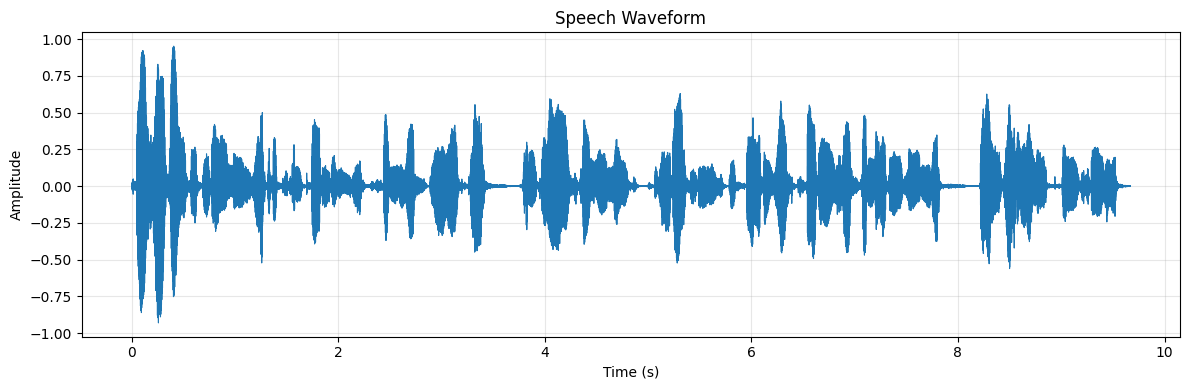

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from scipy.linalg import solve_toeplitz

plt.rcParams["figure.figsize"] = (12, 4)


def load_wav_mono(path: str):
    fs, data = wavfile.read(path)

    if data.ndim == 2:
        data = data.mean(axis=1)

    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / max_val
    else:
        data = data.astype(np.float32)

    return fs, data


wav_file_path = ""
source_description = "Recorded own voice / dataset sample"

wav_candidates = sorted(Path(".").glob("*.wav"))
if not wav_file_path:
    if wav_candidates:
        wav_file_path = str(wav_candidates[0])
    else:
        raise FileNotFoundError(
            "No .wav file found in the notebook folder. "
            "Set wav_file_path to your speech sample path."
        )

fs, x = load_wav_mono(wav_file_path)
time = np.arange(len(x)) / fs

print(f"Audio file: {wav_file_path}")
print(f"Source: {source_description}")
print(f"Sampling rate: {fs} Hz")
print(f"Duration: {len(x) / fs:.2f} s")

plt.figure()
plt.plot(time, x, linewidth=0.8)
plt.title("Speech Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Question I: FFT Analysis
Use FFT to extract and visualize **pitch, harmonics, and formants** from a speech signal.

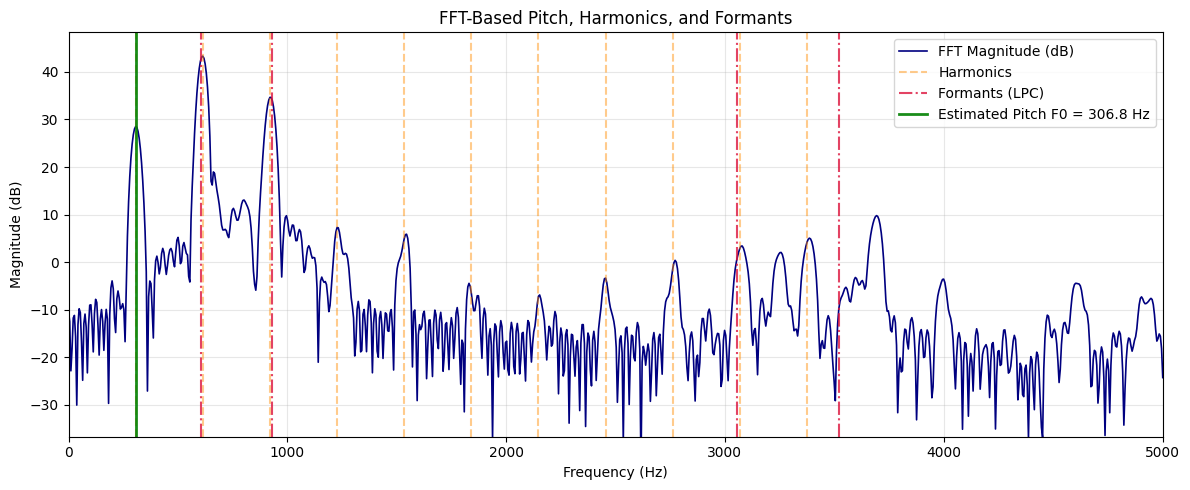

Estimated pitch (F0): 306.85 Hz
Estimated formants (Hz): 604.5, 929.2, 3054.4, 3521.6


In [2]:
def lpc_coefficients(frame, order):
    frame = frame - np.mean(frame)
    if np.max(np.abs(frame)) > 0:
        frame = frame / np.max(np.abs(frame))

    autocorr = np.correlate(frame, frame, mode="full")
    autocorr = autocorr[len(frame) - 1 : len(frame) + order]

    if autocorr[0] == 0:
        return np.r_[1.0, np.zeros(order)]

    toeplitz_col = autocorr[:-1]
    rhs = autocorr[1:]
    a = solve_toeplitz((toeplitz_col, toeplitz_col), rhs)
    return np.r_[1.0, -a]


def estimate_formants_lpc(frame, fs, n_formants=4):
    order = max(10, int(fs / 1000) + 2)
    frame = frame * np.hamming(len(frame))
    a = lpc_coefficients(frame, order)

    roots = np.roots(a)
    roots = roots[np.imag(roots) >= 0]

    angles = np.angle(roots)
    freqs = angles * (fs / (2 * np.pi))

    freqs = np.sort(freqs[(freqs > 90) & (freqs < 5000)])
    return freqs[:n_formants]


frame_len = int(0.04 * fs)
hop = int(0.01 * fs)
energies = []
starts = range(0, len(x) - frame_len, hop)
for s in starts:
    frame = x[s : s + frame_len]
    energies.append(np.sum(frame**2))

best_idx = int(np.argmax(energies))
start = list(starts)[best_idx]
frame = x[start : start + frame_len] * np.hamming(frame_len)

n_fft = 4096
freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
spectrum = np.abs(np.fft.rfft(frame, n=n_fft))
spectrum_db = 20 * np.log10(spectrum + 1e-8)

pitch_band = (freqs >= 70) & (freqs <= 400)
f0 = freqs[pitch_band][np.argmax(spectrum[pitch_band])]

harmonics = []
for k in range(1, 12):
    hk = k * f0
    if hk < freqs[-1]:
        harmonics.append(hk)

formants = estimate_formants_lpc(frame, fs, n_formants=4)

plt.figure(figsize=(12, 5))
plt.plot(freqs, spectrum_db, color="navy", linewidth=1.2, label="FFT Magnitude (dB)")

for i, h in enumerate(harmonics):
    plt.axvline(h, color="darkorange", linestyle="--", alpha=0.45,
                label="Harmonics" if i == 0 else None)

for i, f in enumerate(formants):
    plt.axvline(f, color="crimson", linestyle="-.", alpha=0.8,
                label="Formants (LPC)" if i == 0 else None)

plt.axvline(f0, color="green", linewidth=2, alpha=0.9, label=f"Estimated Pitch F0 = {f0:.1f} Hz")
plt.xlim(0, min(5000, fs / 2))
plt.ylim(np.max(spectrum_db) - 80, np.max(spectrum_db) + 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT-Based Pitch, Harmonics, and Formants")
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Estimated pitch (F0): {f0:.2f} Hz")
print("Estimated formants (Hz):", ", ".join([f"{f:.1f}" for f in formants]))

## Question II: STFT Spectrograms
Use STFT to extract and visualize spectrograms of:
1. Pitch contour
2. Formants

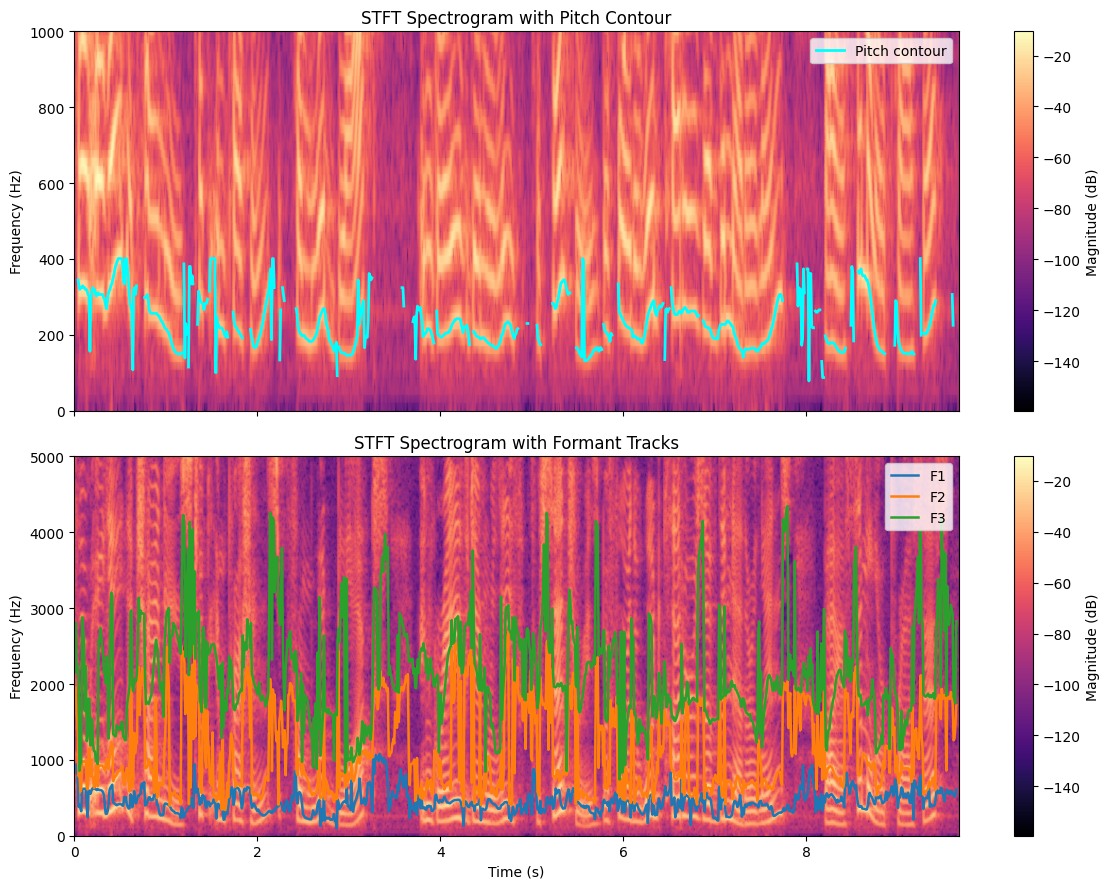

In [3]:
def estimate_pitch_autocorr(signal_1d, fs, frame_ms=40, hop_ms=10, fmin=70, fmax=400):
    frame_len = int(frame_ms * 1e-3 * fs)
    hop_len = int(hop_ms * 1e-3 * fs)
    min_lag = int(fs / fmax)
    max_lag = int(fs / fmin)

    times = []
    pitches = []

    for start in range(0, len(signal_1d) - frame_len, hop_len):
        frame = signal_1d[start : start + frame_len]
        frame = frame - np.mean(frame)
        frame = frame * np.hamming(frame_len)

        ac = np.correlate(frame, frame, mode="full")[frame_len - 1 :]
        if ac[0] <= 1e-8:
            pitches.append(np.nan)
            times.append((start + frame_len / 2) / fs)
            continue

        search = ac[min_lag:max_lag]
        peak_lag = np.argmax(search) + min_lag

        if ac[peak_lag] < 0.25 * ac[0]:
            pitches.append(np.nan)
        else:
            pitches.append(fs / peak_lag)

        times.append((start + frame_len / 2) / fs)

    return np.array(times), np.array(pitches)


def estimate_formant_tracks(signal_1d, fs, frame_ms=30, hop_ms=10, n_tracks=3):
    frame_len = int(frame_ms * 1e-3 * fs)
    hop_len = int(hop_ms * 1e-3 * fs)

    times = []
    tracks = []

    for start in range(0, len(signal_1d) - frame_len, hop_len):
        frame = signal_1d[start : start + frame_len]
        formants_frame = estimate_formants_lpc(frame, fs, n_formants=n_tracks)

        vals = np.full(n_tracks, np.nan)
        vals[: min(len(formants_frame), n_tracks)] = formants_frame[:n_tracks]

        tracks.append(vals)
        times.append((start + frame_len / 2) / fs)

    return np.array(times), np.array(tracks)


nperseg = 1024
noverlap = 768
f_stft, t_stft, Zxx = signal.stft(x, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap)
S_db = 20 * np.log10(np.abs(Zxx) + 1e-8)

t_pitch, pitch_track = estimate_pitch_autocorr(x, fs)
t_formant, formant_tracks = estimate_formant_tracks(x, fs, n_tracks=3)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

pcm1 = axes[0].pcolormesh(t_stft, f_stft, S_db, shading="gouraud", cmap="magma")
axes[0].plot(t_pitch, pitch_track, color="cyan", linewidth=2, label="Pitch contour")
axes[0].set_ylim(0, min(1000, fs / 2))
axes[0].set_title("STFT Spectrogram with Pitch Contour")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].legend(loc="upper right")
fig.colorbar(pcm1, ax=axes[0], label="Magnitude (dB)")

pcm2 = axes[1].pcolormesh(t_stft, f_stft, S_db, shading="gouraud", cmap="magma")
for i in range(formant_tracks.shape[1]):
    axes[1].plot(t_formant, formant_tracks[:, i], linewidth=1.8, label=f"F{i+1}")

axes[1].set_ylim(0, min(5000, fs / 2))
axes[1].set_title("STFT Spectrogram with Formant Tracks")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].legend(loc="upper right")
fig.colorbar(pcm2, ax=axes[1], label="Magnitude (dB)")

plt.tight_layout()
plt.show()

## Question III: Visual Distinguishability Analysis
Analyze whether **pitch, harmonics, and formants** are visually distinguishable based on frequency characteristics in both FFT and STFT.

**Write your observations and comments below.**

In [4]:
valid_pitch = pitch_track[~np.isnan(pitch_track)]
pitch_mean = np.mean(valid_pitch) if len(valid_pitch) else np.nan
pitch_std = np.std(valid_pitch) if len(valid_pitch) else np.nan

formant_summary = []
for i in range(formant_tracks.shape[1]):
    fi = formant_tracks[:, i]
    fi = fi[~np.isnan(fi)]
    if len(fi):
        formant_summary.append((i + 1, float(np.median(fi)), float(np.std(fi))))

print("Q3 Observations")
print("-" * 60)
print(f"1) FFT shows clear harmonic peaks at multiples of F0 (~{f0:.1f} Hz).")
print("2) Harmonics are more visible as discrete frequency lines in FFT.")
print("3) In STFT, pitch contour appears as a low-frequency trajectory over time.")
print("4) Formants appear as broader resonant bands in both FFT envelope and STFT.")

if len(valid_pitch):
    print(f"5) Estimated pitch contour mean ± std: {pitch_mean:.1f} ± {pitch_std:.1f} Hz")

if formant_summary:
    print("6) Formant track statistics (median ± std):")
    for idx, med, sd in formant_summary:
        print(f"   F{idx}: {med:.1f} ± {sd:.1f} Hz")

print("7) Conclusion: pitch and harmonics are easier to separate in FFT, while time-varying behavior (pitch/formants) is clearer in STFT.")

Q3 Observations
------------------------------------------------------------
1) FFT shows clear harmonic peaks at multiples of F0 (~306.8 Hz).
2) Harmonics are more visible as discrete frequency lines in FFT.
3) In STFT, pitch contour appears as a low-frequency trajectory over time.
4) Formants appear as broader resonant bands in both FFT envelope and STFT.
5) Estimated pitch contour mean ± std: 232.7 ± 66.5 Hz
6) Formant track statistics (median ± std):
   F1: 434.1 ± 147.8 Hz
   F2: 889.8 ± 560.6 Hz
   F3: 2000.6 ± 685.3 Hz
7) Conclusion: pitch and harmonics are easier to separate in FFT, while time-varying behavior (pitch/formants) is clearer in STFT.


## Question IV: Narrowband vs Wideband Spectrogram
Take narrower and wider windows and plot:
1. Narrowband spectrogram
2. Wideband spectrogram

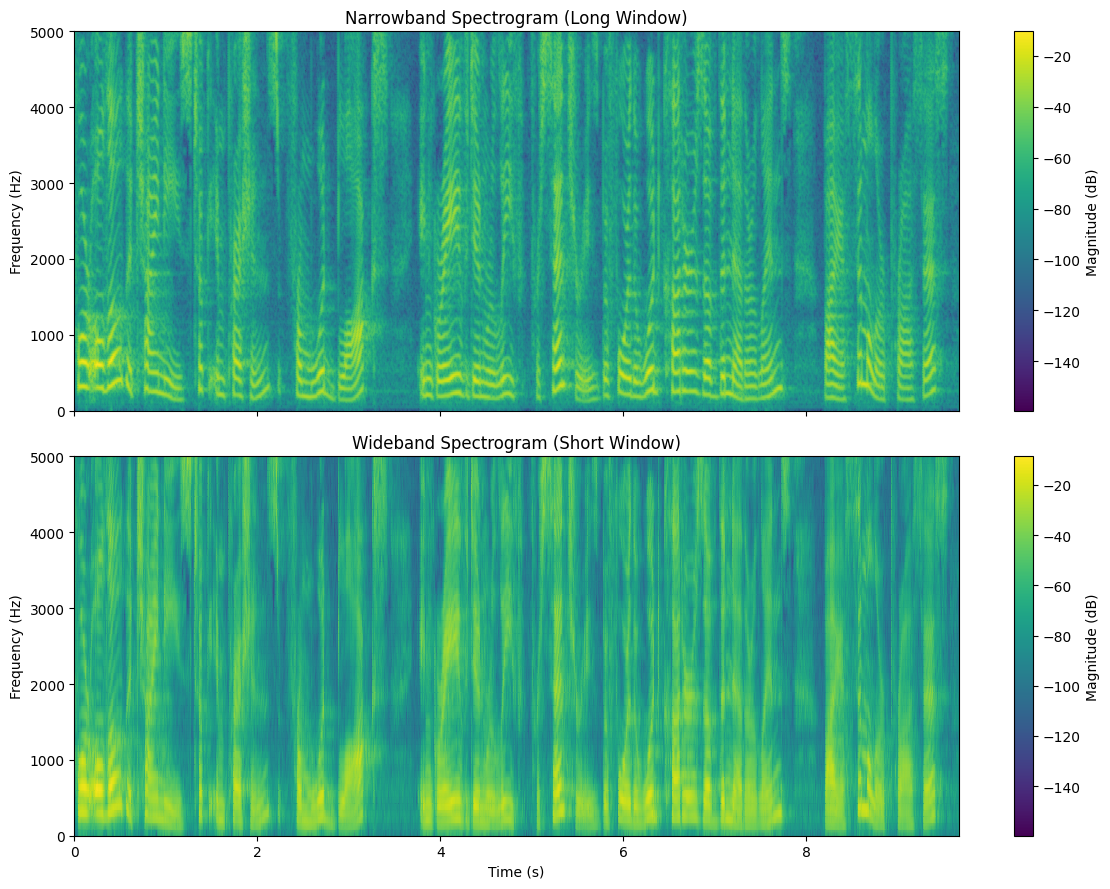

Narrowband vs Wideband Summary
------------------------------------------------------------
Narrowband (long window): clearer harmonics / frequency lines.
Wideband (short window): clearer temporal events and pitch pulses.


In [5]:
f_n, t_n, Z_n = signal.stft(x, fs=fs, window="hann", nperseg=1024, noverlap=960)
S_n_db = 20 * np.log10(np.abs(Z_n) + 1e-8)

f_w, t_w, Z_w = signal.stft(x, fs=fs, window="hann", nperseg=256, noverlap=200)
S_w_db = 20 * np.log10(np.abs(Z_w) + 1e-8)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

pcm_n = axes[0].pcolormesh(t_n, f_n, S_n_db, shading="gouraud", cmap="viridis")
axes[0].set_ylim(0, min(5000, fs / 2))
axes[0].set_title("Narrowband Spectrogram (Long Window)")
axes[0].set_ylabel("Frequency (Hz)")
fig.colorbar(pcm_n, ax=axes[0], label="Magnitude (dB)")

pcm_w = axes[1].pcolormesh(t_w, f_w, S_w_db, shading="gouraud", cmap="viridis")
axes[1].set_ylim(0, min(5000, fs / 2))
axes[1].set_title("Wideband Spectrogram (Short Window)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
fig.colorbar(pcm_w, ax=axes[1], label="Magnitude (dB)")

plt.tight_layout()
plt.show()

print("Narrowband vs Wideband Summary")
print("-" * 60)
print("Narrowband (long window): clearer harmonics / frequency lines.")
print("Wideband (short window): clearer temporal events and pitch pulses.")

## Question V: Inference
Infer and summarize your final result based on all observations from FFT and STFT analyses.

In [6]:
f0_txt = f"{f0:.1f} Hz" if "f0" in globals() else "N/A"

f_medians = []
if "formant_tracks" in globals():
    for i in range(formant_tracks.shape[1]):
        fi = formant_tracks[:, i]
        fi = fi[~np.isnan(fi)]
        if len(fi):
            f_medians.append(f"F{i+1}~{np.median(fi):.0f} Hz")

final_points = [
    f"Estimated fundamental frequency (pitch): {f0_txt}.",
    "FFT is effective for identifying harmonic spacing and resonance peaks.",
    "STFT is effective for analyzing how pitch/formants evolve over time.",
    "Narrowband spectrogram improves frequency detail, while wideband improves time detail.",
    "Overall, pitch, harmonics, and formants are distinguishable and complementary across FFT and STFT views."
]

if f_medians:
    final_points.insert(1, "Typical formant locations: " + ", ".join(f_medians) + ".")

print("Q5 Final Inference")
print("-" * 60)
for i, point in enumerate(final_points, 1):
    print(f"{i}. {point}")

Q5 Final Inference
------------------------------------------------------------
1. Estimated fundamental frequency (pitch): 306.8 Hz.
2. Typical formant locations: F1~434 Hz, F2~890 Hz, F3~2001 Hz.
3. FFT is effective for identifying harmonic spacing and resonance peaks.
4. STFT is effective for analyzing how pitch/formants evolve over time.
5. Narrowband spectrogram improves frequency detail, while wideband improves time detail.
6. Overall, pitch, harmonics, and formants are distinguishable and complementary across FFT and STFT views.
